# Taller (Colab) — Regresión lineal múltiple: coeficientes, significancia y residuales

**Duración sugerida:** 50–60 min de trabajo + sustentación.

## Qué se evalúa hoy
1) **Interpretación de coeficientes** en regresión múltiple (cambio marginal, controlando por, unidades).
2) **Significancia por coeficiente** (t y p-valor, y coherencia con el IC).
3) **Lectura de residuales** (qué dicen y qué alertas sugieren).

---
## Definiciones mínimas (úsalas textual en la sustentación)

### A. Interpretación correcta de un coeficiente (plantilla obligatoria)
Para un predictor Xj:
> “Si Xj aumenta en **1 unidad**, la **nota esperada** cambia en **β̂j** puntos, **manteniendo constantes** los demás predictores del modelo.”

**Siempre debes mencionar:**
- signo (sube/baja),
- magnitud (cuánto),
- unidad (puntos de nota por unidad de Xj),
- y la frase “manteniendo constantes …”.

### B. Significancia (por coeficiente)
- Hipótesis: H0: βj = 0 vs H1: βj ≠ 0.
- t = β̂j / SE(β̂j).
- p-valor: evidencia contra H0 bajo los supuestos del modelo.

### C. Residuales (qué mirar)
- Residual = observado − predicho.
- Si hay patrón (curva/abanico) en residuales vs predichos → posible problema (no linealidad/heterocedasticidad).
- Outliers: residuales muy grandes en valor absoluto.


In [ ]:
# 0) LIBRERÍAS (NO MODIFICAR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(2026)
pd.set_option('display.precision', 4)


## Contexto y variables (común para todos)

**Unidad:** estudiante.

**Y:** `nota` (0 a 5)

**X:**
- `horas` = horas de estudio por semana
- `asistencia` = porcentaje de asistencia (0–100)
- `promedio` = promedio previo (0–5)


In [ ]:
# 1) SIMULACIÓN BASE (NO MODIFICAR)
n = 300

promedio = np.clip(np.random.normal(3.5, 0.5, n), 0, 5)
asistencia = 70 + 8*(promedio-3.5) + np.random.normal(0, 10, n)
asistencia = np.clip(asistencia, 40, 100)
horas = 6 + 2.0*(promedio-3.5) + 0.05*(asistencia-70) + np.random.normal(0, 2.5, n)
horas = np.clip(horas, 0, 25)

eps = np.random.normal(0, 0.35, n)
nota = 0.6 + 0.05*horas + 0.012*asistencia + 0.55*promedio + eps
nota = np.clip(nota, 0, 5)

df = pd.DataFrame({'nota': nota, 'horas': horas, 'asistencia': asistencia, 'promedio': promedio})
df.head()

,nota,horas,asistencia,promedio
0,3.1953,2.2842,52.2924,3.2841
1,3.5160,4.6165,64.9618,2.8036
2,3.9114,2.5652,81.6452,3.6558
3,4.0231,8.3381,63.5462,3.4934
4,4.1592,12.3759,76.2580,4.2249


# Instrucciones del taller (USTEDES escriben el código)

## Entrega: 3 cosas
1) Tu notebook con el código.
2) Un párrafo final (8–10 líneas).
3) 2 gráficas guardadas en el notebook.

---
## Tareas (claras y numeradas)

### Parte 1 — Ajuste del modelo y coeficientes (interpretación)
1. Ajusta el modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Copia (o muestra) la tabla de coeficientes.
3. Interpreta **cada** coeficiente (horas, asistencia, promedio) con la **plantilla obligatoria**.
   - incluye signo, magnitud, unidad y “manteniendo constantes …”.
4. Interpreta el efecto de **+5 horas** usando el coeficiente de `horas`.

### Parte 2 — Significancia (por coeficiente)
5. Para cada predictor (horas, asistencia, promedio), responde:
   - H0 y H1.
   - p-valor: ¿rechazas H0 al 5%?
   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: “significativo” NO es lo mismo que “importante”.

### Parte 3 — Residuales (lectura rápida y profesional)
6. Calcula residuales y valores ajustados (predichos).
7. Haz estas 2 gráficas:
   - (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
   - (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
8. Escribe 3 bullets:
   - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?
   - ¿hay outliers evidentes?
   - ¿qué supuesto podría fallar si ves abanico?

### Parte 4 — Modificación obligatoria (para forzar nueva interpretación)
Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.
9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.
10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
   - ¿por qué cambia el número?
   - ¿cómo cambia la interpretación en palabras?

---
## Párrafo final (8–10 líneas)
Incluye:
- interpretación correcta de los 3 coeficientes (resumida),
- 1 conclusión sobre significancia (sin exagerar causalidad),
- 1 conclusión sobre residuales,
- y 1 línea sobre el cambio de unidades (horas a decenas de horas).


In [ ]:
X_m3 = sm.add_constant(df[['horas', 'asistencia', 'promedio']])
m3 = sm.OLS(df['nota'], X_m3).fit()
print("=====================================================")
print("Parte 1: Ajuste del modelo M3 y tabla de coeficientes")
print("=====================================================")
print(m3.summary())

# 3. Interpretación de coeficientes

b_horas = m3.params['horas']
b_asistencia = m3.params['asistencia']
b_promedio = m3.params['promedio']



Parte 1: Ajuste del modelo M3 y tabla de coeficientes
                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        11:14:46   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

**Parte 1: Interpretación de cada coeficiente**

Interpretación para horas: Si las horas de estudio aumentan en 1 unidad, la nota esperada cambia en 0.0412 puntos, manteniendo constantes los demás predictores del modelo.

Interpretación para asistencia: Si el porcentaje de asistencia aumenta en 1 unidad, la nota esperada cambia en 0.0106 puntos, manteniendo constantes los demás predictores del modelo.

Interpretación para promedio: Si el promedio previo aumenta en 1 unidad, la nota esperada cambia en 0.5753 puntos, manteniendo constantes los demás predictores del modelo.

**Parte 2: Efecto de +5 horas de estudio**

Si las horas de estudio aumentan en 5 unidades, la nota esperada cambia en 0.2059 puntos, manteniendo constantes los demás predictores del modelo.

In [ ]:
print("\n=====================================================")
print("Parte 2: Significancia por coeficiente")
print("=====================================================")

predictors = ['horas', 'asistencia', 'promedio']
alpha = 0.05

predictors = ['horas', 'asistencia', 'promedio']
alpha = 0.05

for p in predictors:
    p_val = m3.pvalues[p]
    ci_low, ci_high = m3.conf_int().loc[p]

    decision = "Rechazamos H0" if p_val < alpha else "No rechazamos H0"
    ci_msg = "incluye 0" if ci_low <= 0 <= ci_high else "no incluye 0"

    print(f"\nPredictor: {p}")
    print(f"p-valor: {p_val:.4f}  {decision}")
    print(f"IC 95%: [{ci_low:.4f}, {ci_high:.4f}]  El intervalo {ci_msg}")


print("\n=====================================================")
print("Nota importante sobre significancia:")
print("La significancia estadística indica que es improbable que un efecto observado se deba al azar, pero no implica que el efecto sea grande o importante en un sentido práctico. Un coeficiente puede ser estadísticamente significativo pero tener una magnitud muy pequeña y, por lo tanto, poca importancia práctica.")



Parte 2: Significancia por coeficiente

Predictor: horas
p-valor: 0.0000  Rechazamos H0
IC 95%: [0.0236, 0.0587]  El intervalo no incluye 0

Predictor: asistencia
p-valor: 0.0000  Rechazamos H0
IC 95%: [0.0063, 0.0150]  El intervalo no incluye 0

Predictor: promedio
p-valor: 0.0000  Rechazamos H0
IC 95%: [0.4762, 0.6744]  El intervalo no incluye 0

Nota importante sobre significancia:
La significancia estadística indica que es improbable que un efecto observado se deba al azar, pero no implica que el efecto sea grande o importante en un sentido práctico. Un coeficiente puede ser estadísticamente significativo pero tener una magnitud muy pequeña y, por lo tanto, poca importancia práctica.


Los resultados muestran que horas de estudio, asistencia y promedio previo son estadísticamente significativos (p < 0.05). En todos los casos se rechaza la hipótesis nula y los intervalos de confianza al 95% no incluyen el valor cero, lo que confirma que estas variables influyen de forma significativa en la nota final.

En conclusión, los estudiantes que estudian más horas, asisten con mayor regularidad a clases y tienen un mejor promedio previo tienden a obtener notas finales más altas.


Parte 3: Residuales y Gráficas


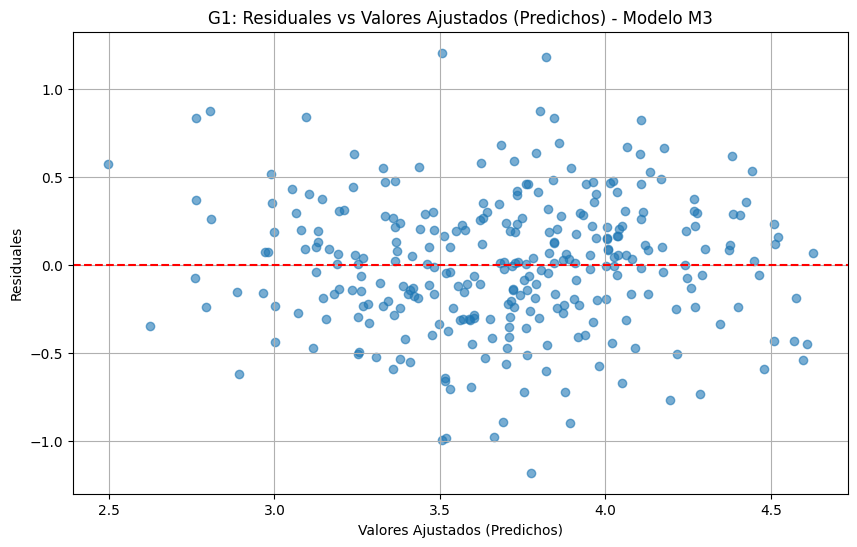

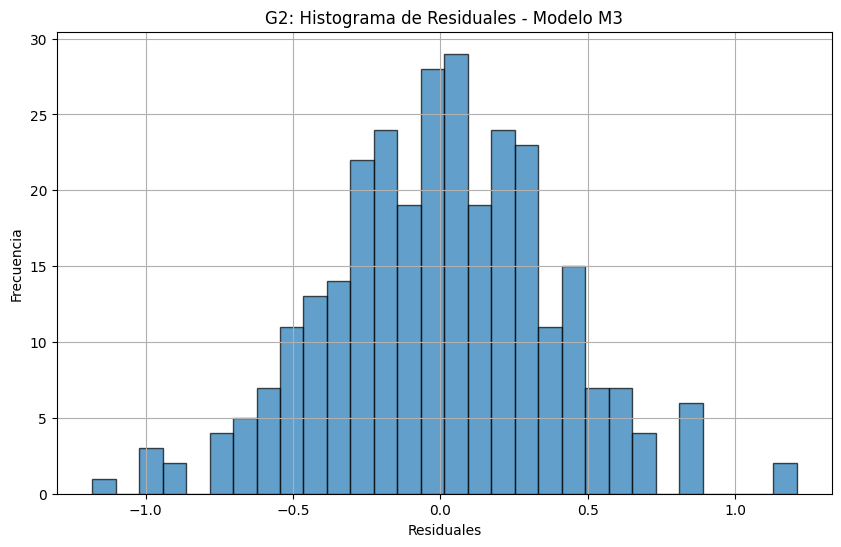

In [ ]:
print("\n=====================================================")
print("Parte 3: Residuales y Gráficas")
print("=====================================================")

# 6. Calcula residuales y valores ajustados (predichos)
residuals = m3.resid
fitted_values = m3.fittedvalues

# 7. Haz estas 2 gráficas:
# (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('G1: Residuales vs Valores Ajustados (Predichos) - Modelo M3')
plt.xlabel('Valores Ajustados (Predichos)')
plt.ylabel('Residuales')
plt.grid(True)
plt.show()

# (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('G2: Histograma de Residuales - Modelo M3')
plt.xlabel('Residuales')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

Patrón en los residuales:
*  Los puntos se ven como una nube alrededor de cero, sin forma clara

Outliers:
* Existen algunos residuales alejados del centro, pero no se observan valores atípicos severos que afecten significativamente el modelo

Abanico:
* No se observa un patrón de abanico, por lo que el supuesto de homocedasticidad parece cumplirse.

conclusión: el gráfico de residuales vs valores ajustados muestra una dispersión aleatoria alrededor de cero, sin patrones sistemáticos ni forma de abanico. Esto sugiere que se cumplen los supuestos de linealidad y homocedasticidad, y que el modelo de regresión lineal es adecuado.

In [ ]:
print("\n=====================================================")
print("Parte 4: Modificación obligatoria (cambio de unidades)")
print("=====================================================")

# 9. Crea horas10 = horas / 10 y ajusta el modelo M3b
df['horas10'] = df['horas'] / 10
X_m3b = sm.add_constant(df[['horas10', 'asistencia', 'promedio']])
m3b = sm.OLS(df['nota'], X_m3b).fit()

print("\n=====================================================")
print("Ajuste del modelo M3b y tabla de coeficientes")
print("=====================================================")
print(m3b.summary())

# 10. Compara B_horas (M3) vs B_horas10 (M3b)
b_horas_m3 = m3.params['horas']
b_horas10_m3b = m3b.params['horas10']


Parte 4: Modificación obligatoria (cambio de unidades)

Ajuste del modelo M3b y tabla de coeficientes
                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        11:14:47   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

Coeficientes:

* Modelo M3 (horas): 0.0412
* Modelo M3b (10 horas): 0.4117

Por qué cambia el número:
* El coeficiente cambia porque la unidad de la variable cambió. En M3 se mide en 1 hora, y en M3b en 10 horas. Como 1 unidad de horas10 equivale a 10 horas, el coeficiente se multiplica por 10.

Conclusion:

* M3: “Si estudias 1 hora más, la nota aumenta 0.0412 puntos.”

* M3b: “Si estudias 10 horas más (1 unidad de horas10), la nota aumenta 0.4117 puntos.”

* el efecto real en la nota es el mismo, solo cambia el número porque cambió la escala de la variable.

La nota de los estudiantes aumenta con más horas de estudio, asistencia y un mejor promedio previo, y todas las variables son estadísticamente significativas. Los residuales no muestran patrones claros, indicando que el modelo se ajusta bien, y al medir las horas en decenas, el efecto del estudio se refleja de manera proporcional.